In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('hospital_patients.csv')

In [3]:
df

,PatientID,Name,Age,Gender,Disease,TreatmentCost,DaysAdmitted
0,2001,Patient_1,17,Male,BP,24400,16
1,2002,Patient_2,47,Male,Asthma,3415,4
2,2003,Patient_3,66,Male,Asthma,24095,12
3,2004,Patient_4,60,Female,Fever,10616,12
4,2005,Patient_5,75,Female,Covid,38572,14
...,...,...,...,...,...,...,...
95,2096,Patient_96,17,Female,Asthma,35286,14
96,2097,Patient_97,60,Male,Covid,47008,2
97,2098,Patient_98,58,Male,Fever,35547,12
98,2099,Patient_99,63,Female,BP,17247,10


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   PatientID      100 non-null    int64
 1   Name           100 non-null    str  
 2   Age            100 non-null    int64
 3   Gender         100 non-null    str  
 4   Disease        100 non-null    str  
 5   TreatmentCost  100 non-null    int64
 6   DaysAdmitted   100 non-null    int64
dtypes: int64(4), str(3)
memory usage: 5.6 KB


In [5]:
df.sample(5)

,PatientID,Name,Age,Gender,Disease,TreatmentCost,DaysAdmitted
53,2054,Patient_54,31,Male,Covid,23911,17
34,2035,Patient_35,17,Female,Fever,39285,7
20,2021,Patient_21,38,Male,Asthma,44862,7
22,2023,Patient_23,47,Male,Fever,20455,10
73,2074,Patient_74,61,Female,Fever,39863,4


# NUMPY

In [6]:
np.average(df['TreatmentCost'])

np.float64(28566.58)

In [7]:
np.max(df['DaysAdmitted'])

np.int64(19)

In [8]:
np.max(df['Age'])

np.int64(78)

# PANDAS

In [9]:
df.sample(3)

,PatientID,Name,Age,Gender,Disease,TreatmentCost,DaysAdmitted
23,2024,Patient_24,60,Male,Diabetes,29208,18
98,2099,Patient_99,63,Female,BP,17247,10
58,2059,Patient_59,51,Male,BP,9765,19


In [10]:
# df.groupby('Disease').count('patientID')
df.groupby('Disease')['PatientID'].count()


Disease
Asthma      14
BP          14
Covid       21
Diabetes    24
Fever       27
Name: PatientID, dtype: int64

In [21]:
df.groupby('Disease').agg(patient_count=('PatientID', 'count'))

# https://chatgpt.com/s/t_6a120b77b1748191a1d4abf53b1c9899


,patient_count
Disease,
Asthma,14
BP,14
Covid,21
Diabetes,24
Fever,27


In [12]:
# df['Name'].df['DaysAdmitted']>10
# df.loc[df['DaysAdmitted'] > 10, 'Name']
# df.loc[df['DaysAdmitted'] > 10, ['Name', 'DaysAdmitted']]
df.loc[df['DaysAdmitted'] > 10, ['Name', 'DaysAdmitted']].head()

,Name,DaysAdmitted
0,Patient_1,16
2,Patient_3,12
3,Patient_4,12
4,Patient_5,14
5,Patient_6,16


In [22]:
df.head()

,PatientID,Name,Age,Gender,Disease,TreatmentCost,DaysAdmitted
0,2001,Patient_1,17,Male,BP,24400,16
1,2002,Patient_2,47,Male,Asthma,3415,4
2,2003,Patient_3,66,Male,Asthma,24095,12
3,2004,Patient_4,60,Female,Fever,10616,12
4,2005,Patient_5,75,Female,Covid,38572,14


In [13]:
df.loc[df['DaysAdmitted'] > 10].shape[0]

45

In [14]:
# df['Name','TreatmentCost'].sort_values(by='TreatmentCost',ascending=False)
df[['Name', 'TreatmentCost']].sort_values(by='TreatmentCost', ascending=False).head(5)


,Name,TreatmentCost
67,Patient_68,49213
16,Patient_17,48981
9,Patient_10,48148
40,Patient_41,47853
93,Patient_94,47788


In [15]:
df.groupby('Gender')['PatientID'].count()

Gender
Female    53
Male      47
Name: PatientID, dtype: int64

# MATPLOTLIB

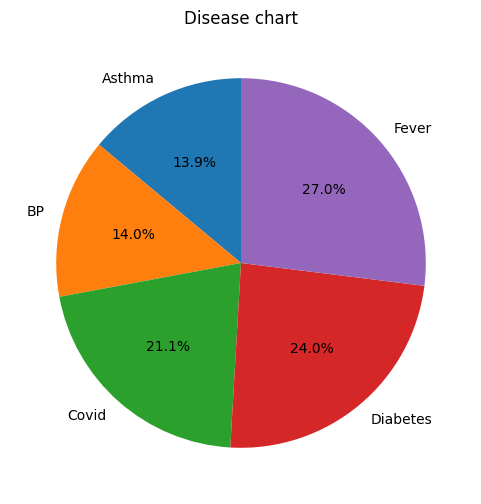

In [16]:
import matplotlib.pyplot as plt

# Group by Product and sum Sales
product_sales = df.groupby('Disease')['PatientID'].sum()

# Create pie chart
plt.figure(figsize=(6,6))
plt.pie(product_sales.values,
        labels=product_sales.index,
        autopct='%1.1f%%',
        startangle=90)

# Title
plt.title('Disease chart')
plt.show()


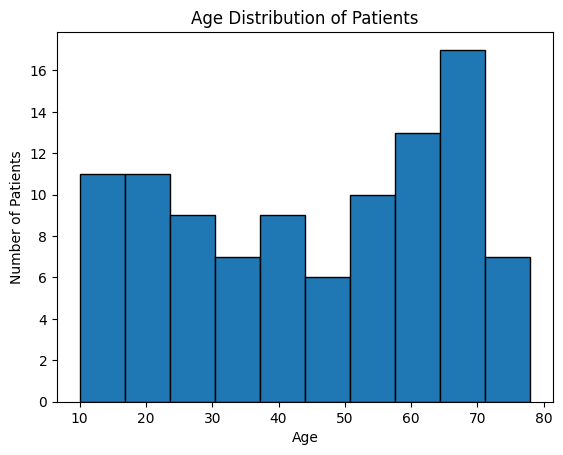

In [17]:
import matplotlib.pyplot as plt

# Histogram of Age column
plt.hist(df['Age'], bins=10, edgecolor='black')

# Add labels and title
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.title('Age Distribution of Patients')

plt.show()


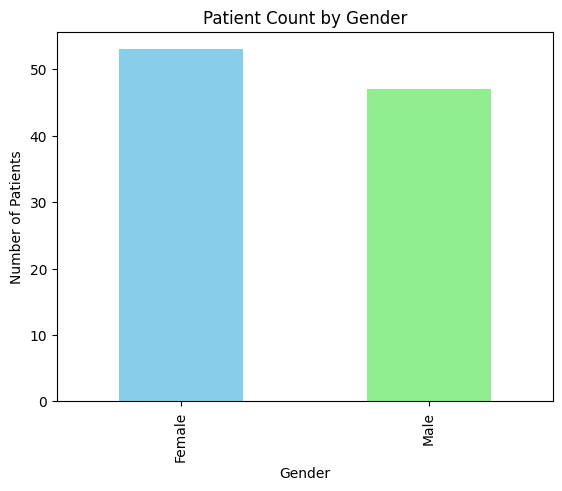

In [18]:
import matplotlib.pyplot as plt

# Count genders
gender_counts = df['Gender'].value_counts()

# Plot bar chart
gender_counts.plot(kind='bar', color=['skyblue', 'lightgreen'])

# Add labels and title
plt.xlabel('Gender')
plt.ylabel('Number of Patients')
plt.title('Patient Count by Gender')

plt.show()
